In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)

def loss(theta):
    x, y = theta
    return 10*x**2 + y**2

def grad(theta):
    x, y = theta
    return np.array([20*x, 2*y])

def plot_contours():
    x = np.linspace(-2, 2, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = 10*X**2 + Y**2
    plt.contour(X, Y, Z, levels=30, alpha=0.5)

def plot_path(path, label):
    path = np.array(path)
    plt.plot(path[:,0], path[:,1], marker='o', label=label)


In [3]:
def sgd(theta, lr, steps):
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        theta = theta - lr * g
        path.append(theta.copy())
    return path


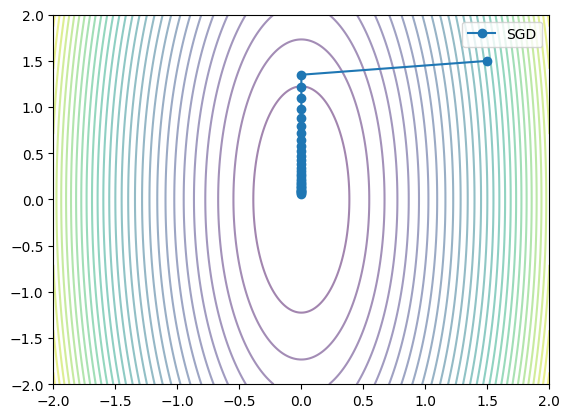

In [4]:
theta0 = np.array([1.5, 1.5])
path_sgd = sgd(theta0, lr=0.05, steps=30)

plot_contours()
plot_path(path_sgd, "SGD")
plt.legend()
plt.show()

In [5]:
def momentum(theta, lr, beta, steps):
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        v = beta * v + g
        theta = theta - lr * v
        path.append(theta.copy())
    return path


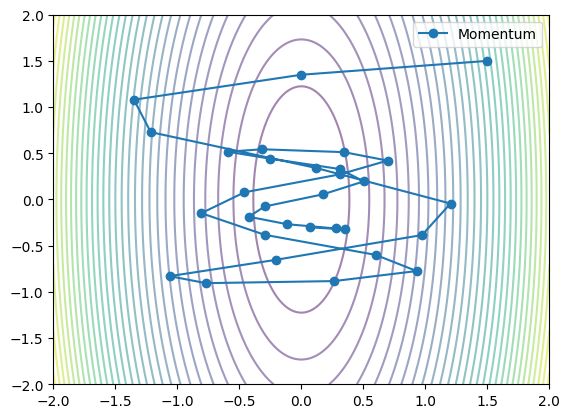

In [6]:
path_mom = momentum(theta0, lr=0.05, beta=0.9, steps=30)

plot_contours()
plot_path(path_mom, "Momentum")
plt.legend()
plt.show()


In [7]:
def adagrad(theta, lr, eps, steps):
    G = np.zeros_like(theta)
    path = [theta.copy()]
    
    for _ in range(steps):
        g = grad(theta)
        G += g**2
        theta = theta - lr * g / (np.sqrt(G) + eps)
        path.append(theta.copy())
        
    return path


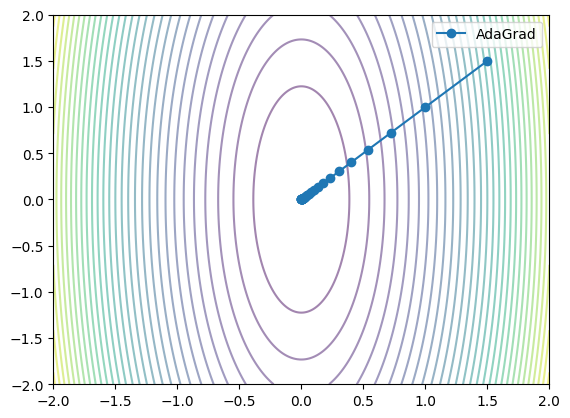

In [8]:
path_adagrad = adagrad(theta0, lr=0.5, eps=1e-8, steps=30)

plot_contours()
plot_path(path_adagrad, "AdaGrad")
plt.legend()
plt.show()


In [9]:
def rmsprop(theta, lr, beta, eps, steps):
    s = np.zeros_like(theta)
    path = [theta.copy()]
    
    for _ in range(steps):
        g = grad(theta)
        s = beta * s + (1 - beta) * g**2
        theta = theta - lr * g / (np.sqrt(s) + eps)
        path.append(theta.copy())
        
    return path


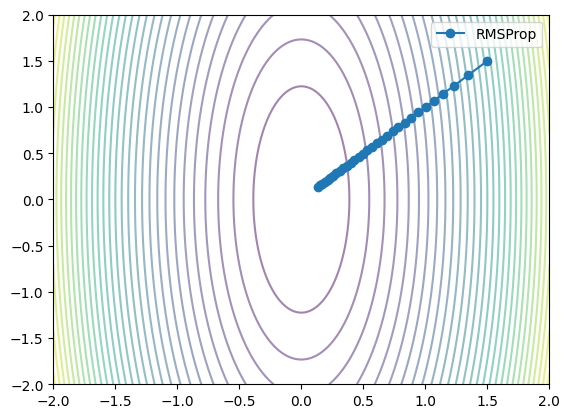

In [ ]:
path_rms = rmsprop(theta0, lr=0.05, beta=0.9, eps=1e-8, steps=30)

plot_contours()
plot_path(path_rms, "RMSProp")
plt.legend()
plt.show()


In [11]:
def adam(theta, lr, beta1, beta2, eps, steps):
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    path = [theta.copy()]
    
    for t in range(1, steps + 1):
        g = grad(theta)
        
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())
        
    return path


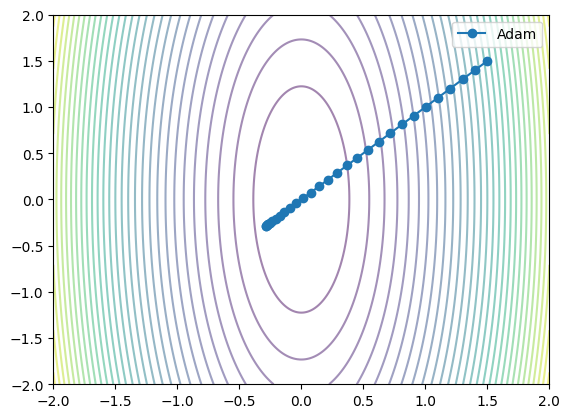

In [12]:
path_adam = adam(
    theta0,
    lr=0.1,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    steps=30
)

plot_contours()
plot_path(path_adam, "Adam")
plt.legend()
plt.show()


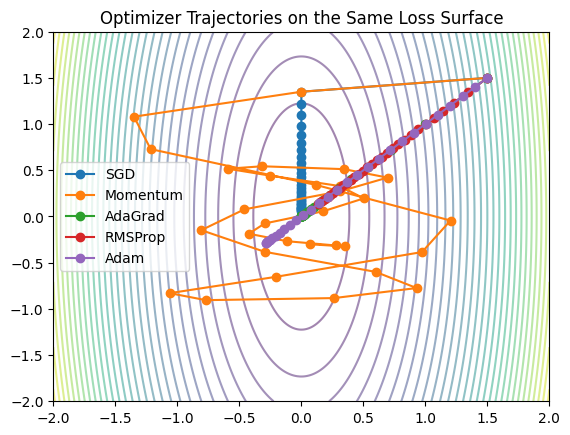

In [13]:
plot_contours()

plot_path(path_sgd, "SGD")
plot_path(path_mom, "Momentum")
plot_path(path_adagrad, "AdaGrad")
plot_path(path_rms, "RMSProp")
plot_path(path_adam, "Adam")

plt.legend()
plt.title("Optimizer Trajectories on the Same Loss Surface")
plt.show()


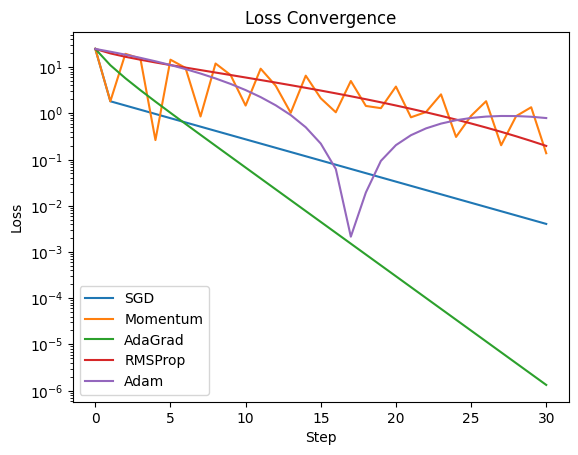

In [14]:
def compute_losses(path):
    return [loss(p) for p in path]

plt.plot(compute_losses(path_sgd), label="SGD")
plt.plot(compute_losses(path_mom), label="Momentum")
plt.plot(compute_losses(path_adagrad), label="AdaGrad")
plt.plot(compute_losses(path_rms), label="RMSProp")
plt.plot(compute_losses(path_adam), label="Adam")

plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Convergence")
plt.show()
